In [1]:
import anndata
from anndata import AnnData
import pandas as pd

#read in the gtf file to get the gene names and their corresponding chromosome locations & TSS
gtf_file = "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/genomic.gtf"
gtf_df = pd.read_csv(gtf_file, sep="\t", header=None, comment="#")
gtf_df.columns = ["chr", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"]
gtf_df["gene_name"] = gtf_df["attribute"].str.extract('gene_name "([^"]+)"')
gtf_df["gene_id"] = gtf_df["attribute"].str.extract('gene_id "([^"]+)"')
gtf_df = gtf_df[gtf_df["feature"] == "gene"]
print(gtf_df.tail())  

#load the pb_atac_ct peak names without headers and index column
pb_atac_ct_peaks = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes/filtered_peaks_ct.csv", header= None,index_col=None)

                 chr  source feature  start    end score strand frame  \
1801098  NC_002333.2  RefSeq    gene  14714  15232     .      -     .   
1801104  NC_002333.2  RefSeq    gene  15233  15301     .      -     .   
1801107  NC_002333.2  RefSeq    gene  15308  16448     .      +     .   
1801113  NC_002333.2  RefSeq    gene  16449  16520     .      +     .   
1801116  NC_002333.2  RefSeq    gene  16527  16596     .      -     .   

                                                 attribute gene_name gene_id  
1801098  gene_id "ND6"; transcript_id ""; db_xref "Gene...       NaN     ND6  
1801104  gene_id "trnE"; transcript_id ""; db_xref "Gen...       NaN    trnE  
1801107  gene_id "CYTB"; transcript_id ""; db_xref "Gen...       NaN    CYTB  
1801113  gene_id "trnT"; transcript_id ""; db_xref "Gen...       NaN    trnT  
1801116  gene_id "trnP"; transcript_id ""; db_xref "Gen...       NaN    trnP  


In [2]:
#check the number of peak names in each file
print(len(pb_atac_ct_peaks))
print(pb_atac_ct_peaks.head())

640835
             0
0            0
1     1-32-526
2  1-2372-3057
3  1-3427-4032
4  1-4469-7268


In [3]:
#remove the first row of the pb_atac_ct_peaks (and pb_atac_ct_time_peaks)
pb_atac_ct_peaks = pb_atac_ct_peaks.iloc[1:]

#give the column a name "peaks"
pb_atac_ct_peaks = pb_atac_ct_peaks.rename(columns={0: "peaks"})

#check the number of peak names in each file
print("Number of peaks in pb_atac_ct:", len(pb_atac_ct_peaks[pb_atac_ct_peaks["peaks"].notnull()]))

#show the first few rows of each file
print("First few rows of pb_atac_ct_peaks:")
print(pb_atac_ct_peaks.head())

#create a chromosome number column by splitting the peaks column at the underscore and taking the first part
pb_atac_ct_peaks["chr"] = pb_atac_ct_peaks["peaks"].str.split("-").str[0]       
print(pb_atac_ct_peaks.head())

#create peak coordinates (expected format: "chr_number-start-end")
peak_parts = pb_atac_ct_peaks["peaks"].astype(str).str.split("-", expand=True)
pb_atac_ct_peaks["chr_number"] = pd.to_numeric(peak_parts[0], errors="coerce")
pb_atac_ct_peaks["peak_start"] = pd.to_numeric(peak_parts[1], errors="coerce")
pb_atac_ct_peaks["peak_end"] = pd.to_numeric(peak_parts[2], errors="coerce")

#show the dropped rows (if any)
dropped_rows = pb_atac_ct_peaks[pb_atac_ct_peaks[["chr_number", "peak_start", "peak_end"]].isnull().any(axis=1)]
print("Dropped rows:")
print(dropped_rows)

# Keep only peaks with valid numeric chromosome/start/end
pb_atac_ct_peaks = pb_atac_ct_peaks.dropna(subset=["chr_number", "peak_start", "peak_end"]).copy()
pb_atac_ct_peaks[["chr_number", "peak_start", "peak_end"]] = (
    pb_atac_ct_peaks[["chr_number", "peak_start", "peak_end"]].astype(int)
)


Number of peaks in pb_atac_ct: 640834
First few rows of pb_atac_ct_peaks:
         peaks
1     1-32-526
2  1-2372-3057
3  1-3427-4032
4  1-4469-7268
5  1-9541-9969
         peaks chr
1     1-32-526   1
2  1-2372-3057   1
3  1-3427-4032   1
4  1-4469-7268   1
5  1-9541-9969   1
Dropped rows:
                 peaks chr  chr_number  peak_start  peak_end
640833      MT-22-3567  MT         NaN          22      3567
640834  MT-13233-16532  MT         NaN       13233     16532


In [4]:
#Subset the columns to only include gene_id, chr, start, end, strand, then keep only chr starting with "NC"
TSS_subset = gtf_df[["gene_id", "chr", "start", "end", "strand"]]
TSS_subset = TSS_subset[TSS_subset["chr"].str.startswith("NC")]    
#remove mitochondrial chromosome
TSS_subset = TSS_subset[~TSS_subset["chr"].str.endswith(".2")]
unique_chromosomes = TSS_subset["chr"].unique()
print(unique_chromosomes)

['NC_007112.7' 'NC_007113.7' 'NC_007114.7' 'NC_007115.7' 'NC_007116.7'
 'NC_007117.7' 'NC_007118.7' 'NC_007119.7' 'NC_007120.7' 'NC_007121.7'
 'NC_007122.7' 'NC_007123.7' 'NC_007124.7' 'NC_007125.7' 'NC_007126.7'
 'NC_007127.7' 'NC_007128.7' 'NC_007129.7' 'NC_007130.7' 'NC_007131.7'
 'NC_007132.7' 'NC_007133.7' 'NC_007134.7' 'NC_007135.7' 'NC_007136.7']


In [5]:
#Filtering the gene_id column by the gene names in csv file
gene_names = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes/filtered_genes_ct.csv", header=None, index_col=None)
gene_names = gene_names.iloc[:, 0].tolist()  # Convert the single column to a list
TSS_filtered = TSS_subset[TSS_subset["gene_id"].isin(gene_names)]
print("Number of genes in TSS_filtered:", len(TSS_filtered))
print("First few rows of TSS_filtered:")

#show some gene names in the list, which were not filtered by the gene names in the csv file
unfiltered_genes = [gene for gene in dict.fromkeys(gene_names) if gene not in TSS_filtered["gene_id"].unique()]  
print("Some gene names that were not in the TSS_subset:")
print(unfiltered_genes[:10])  # Print the first 10 unfiltered gene names

#Show if phtf2 is in the TSS_filtered gene_id column
if "phtf2" in TSS_filtered["gene_id"].values:
    print("phtf2 is in the TSS_filtered gene_id column")
else:
    print("phtf2 is not in the TSS_filtered gene_id column")    

Number of genes in TSS_filtered: 19380
First few rows of TSS_filtered:
Some gene names that were not in the TSS_subset:
['0', 'phtf2.1', 'CU856344.1', 'ptpro.1', 'RERG', 'CABZ01085275.1', 'FO834823.1', 'dynlt1', 'BX890562.1', 'BX890562.3']
phtf2 is in the TSS_filtered gene_id column


In [7]:
#Saving the unfiltered gene names to a csv file
unfiltered_genes_df = pd.DataFrame(unfiltered_genes, columns=["unfiltered_gene_names"])
unfiltered_genes_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/unfiltered_genes_windows.csv", index=False)

#Saving the filtered gene names to a csv file
filtered_genes_df = pd.DataFrame(TSS_filtered["gene_id"].unique(), columns=["filtered_gene_names"])
filtered_genes_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/filtered_genes_windows.csv", index=False)

In [6]:
#find gene names in gene_name list that start with "NC" and count how many there are
nuclear_genes = [gene for gene in gene_names if gene.startswith("NC")]
print(f"Number of genes with 'NC' in their name: {len(nuclear_genes)}")

mt_genes = [gene for gene in gene_names if gene.startswith("MT")]
print(f"Number of genes with 'MT' in their name: {len(mt_genes)}")  

Number of genes with 'NC' in their name: 26
Number of genes with 'MT' in their name: 2


In [7]:
TSS_filtered.head()

,gene_id,chr,start,end,strand
0,rpl24,NC_007112.7,6642,11878,-
16,cep97,NC_007112.7,11961,16373,+
67,nfkbiz,NC_007112.7,18631,23837,+
95,eed,NC_007112.7,27688,34330,+
123,hikeshi,NC_007112.7,36734,39191,+


In [8]:
import numpy as np

def tss_window(chrom, tss, strand, upstream=500, downstream=100):
    if strand == '+':
        start = tss - upstream
        end   = tss + downstream
    else:  # '-'
        start = tss - downstream
        end   = tss + upstream
    return chrom, max(0, start), end

In [10]:
#Creating a window of 10kb to 100kb around the TSS of each gene increasing with 10kb increments, and adding the TSS column to the TSS_filtered dataframe
TSS_filtered["TSS"] = TSS_filtered.apply(lambda row: row["start"] if row["strand"] == "+" else row["end"], axis=1) 

#Creating the windows around the TSS for each gene, and adding them as new columns to the TSS_filtered dataframe repectively for the negative and positive strand genes
TSS_filtered["TSS_5kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 5000 if row['strand'] == '+' else row["TSS"] + 5000, axis=1)
TSS_filtered["TSS_5kb_pos"] = TSS_filtered.apply(lambda row: row["TSS"] + 5000 if row['strand'] == '+' else row["TSS"] - 5000, axis=1)
TSS_filtered["TSS_10kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 10000 if row['strand'] == '+' else row["TSS"] +10000, axis=1)
TSS_filtered["TSS_10kb_pos"] = TSS_filtered.apply(lambda row: row["TSS"] + 10000 if row['strand'] == '+' else row["TSS"] - 10000, axis=1) 
TSS_filtered["TSS_20kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 20000 if row['strand'] == '+' else row["TSS"] +20000, axis=1)
TSS_filtered["TSS_20kb_pos"] = TSS_filtered.apply(lambda row: row["TSS"] + 20000 if row['strand'] == '+' else row["TSS"] - 20000, axis=1)
TSS_filtered["TSS_30kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 30000 if row['strand'] == '+' else row["TSS"] +30000, axis=1)
TSS_filtered["TSS_30kb_pos"] = TSS_filtered.apply(lambda row: row["TSS"] + 30000 if row['strand'] == '+' else row["TSS"] - 30000, axis=1)
TSS_filtered["TSS_40kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 40000 if row['strand'] == '+' else row["TSS"] +40000, axis=1)
TSS_filtered["TSS_40kb_pos"] = TSS_filtered.apply(lambda row: row["TSS"] + 40000 if row['strand'] == '+' else row["TSS"] - 40000, axis=1)
TSS_filtered["TSS_50kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 50000 if row['strand'] == '+' else row["TSS"] +50000, axis=1)
TSS_filtered["TSS_50kb_pos"] = TSS_filtered.apply(lambda row: row["TSS"] + 50000 if row['strand'] == '+' else row["TSS"] - 50000, axis=1)
TSS_filtered["TSS_60kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 60000 if row['strand'] == '+' else row["TSS"] +60000, axis=1)
TSS_filtered["TSS_60kb_pos"] = TSS_filtered.apply(lambda row: row["TSS"] + 60000 if row['strand'] == '+' else row["TSS"] - 60000, axis=1)
TSS_filtered["TSS_70kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 70000 if row['strand'] == '+' else row["TSS"] +70000, axis=1)
TSS_filtered["TSS_70kb_pos"] = TSS_filtered.apply(lambda row: row["TSS"] + 70000 if row['strand'] == '+' else row["TSS"] - 70000, axis=1)
TSS_filtered["TSS_80kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 80000 if row['strand'] == '+' else row["TSS"] +80000, axis=1)
TSS_filtered["TSS_80kb_pos"] = TSS_filtered.apply(lambda row: row["TSS"] + 80000 if row['strand'] == '+' else row["TSS"] - 80000, axis=1)
TSS_filtered["TSS_90kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 90000 if row['strand'] == '+' else row["TSS"] +90000, axis=1)
TSS_filtered["TSS_90kb_pos"] = TSS_filtered.apply(lambda row: row["TSS"] + 90000 if row['strand'] == '+' else row["TSS"] - 90000, axis=1)
TSS_filtered["TSS_100kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 100000 if row['strand'] == '+' else row["TSS"] +100000, axis=1)
TSS_filtered["TSS_100kb_pos"] = TSS_filtered.apply(lambda row: row["TSS"] + 100000 if row['strand'] == '+' else(row ["TSS"] - 100000), axis=1)

TSS_filtered.head()


/tmp/ipykernel_4130197/2823197999.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered["TSS"] = TSS_filtered.apply(lambda row: row["start"] if row["strand"] == "+" else row["end"], axis=1)
/tmp/ipykernel_4130197/2823197999.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered["TSS_5kb_neg"] = TSS_filtered.apply(lambda row: row["TSS"] - 5000 if row['strand'] == '+' else row["TSS"] + 5000, axis=1)
/tmp/ipykernel_4130197/2823197999.py:6: SettingWithCopyWarning: 
A value is trying to be s

,gene_id,chr,start,end,strand,TSS,TSS_5kb_neg,TSS_5kb_pos,TSS_10kb_neg,TSS_10kb_pos,...,TSS_60kb_neg,TSS_60kb_pos,TSS_70kb_neg,TSS_70kb_pos,TSS_80kb_neg,TSS_80kb_pos,TSS_90kb_neg,TSS_90kb_pos,TSS_100kb_neg,TSS_100kb_pos
0,rpl24,NC_007112.7,6642,11878,-,11878,16878,6878,21878,1878,...,71878,-48122,81878,-58122,91878,-68122,101878,-78122,111878,-88122
16,cep97,NC_007112.7,11961,16373,+,11961,6961,16961,1961,21961,...,-48039,71961,-58039,81961,-68039,91961,-78039,101961,-88039,111961
67,nfkbiz,NC_007112.7,18631,23837,+,18631,13631,23631,8631,28631,...,-41369,78631,-51369,88631,-61369,98631,-71369,108631,-81369,118631
95,eed,NC_007112.7,27688,34330,+,27688,22688,32688,17688,37688,...,-32312,87688,-42312,97688,-52312,107688,-62312,117688,-72312,127688
123,hikeshi,NC_007112.7,36734,39191,+,36734,31734,41734,26734,46734,...,-23266,96734,-33266,106734,-43266,116734,-53266,126734,-63266,136734


In [11]:
#counting the number of genes on each chromosome that have a negative starting position on the chromosome for each window size respectively for the negative and positive strand genes
for window in [ "5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]:
    count = len(TSS_filtered[((TSS_filtered["strand"] == "-") & (TSS_filtered[f"TSS_{window}_pos"] < 0)) | ((TSS_filtered["strand"] == "+") & (TSS_filtered[f"TSS_{window}_neg"] < 0))])

    print(f"Number of genes with negative starting position for {window} window: {count}")

#counting the number of genes on each chromosome that have a negative ending position on the chromosome for each window size respectively for the negative and positive strand genes
for window in [ "5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]:
    count = len(TSS_filtered[((TSS_filtered["strand"] == "-") & (TSS_filtered[f"TSS_{window}_neg"] < 0)) | ((TSS_filtered["strand"] == "+") & (TSS_filtered[f"TSS_{window}_pos"] < 0))])
    if count == 0:
        print(f"Number of genes with negative ending position for {window} window: {count}")


Number of genes with negative starting position for 5kb window: 4
Number of genes with negative starting position for 10kb window: 7
Number of genes with negative starting position for 20kb window: 17
Number of genes with negative starting position for 30kb window: 24
Number of genes with negative starting position for 40kb window: 33
Number of genes with negative starting position for 50kb window: 42
Number of genes with negative starting position for 60kb window: 48
Number of genes with negative starting position for 70kb window: 59
Number of genes with negative starting position for 80kb window: 67
Number of genes with negative starting position for 90kb window: 74
Number of genes with negative starting position for 100kb window: 82
Number of genes with negative ending position for 5kb window: 0
Number of genes with negative ending position for 10kb window: 0
Number of genes with negative ending position for 20kb window: 0
Number of genes with negative ending position for 30kb windo

In [12]:
#show the number of genes on each window size
for window in ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]:
    count = TSS_filtered[f"TSS_{window}_pos"].notna().sum()
    print(f"Number of genes for {window} window: {count}") 

#show the value of minimum start for each window size 
for window in ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]:
    min_start = TSS_filtered[((TSS_filtered["strand"] == "-") & (TSS_filtered[f"TSS_{window}_pos"] < 0)) | ((TSS_filtered["strand"] == "+") & (TSS_filtered[f"TSS_{window}_neg"] < 0))].min()
    print(f"Minimum start position for {window} window: {min_start[f'TSS_{window}_pos'] | min_start[f'TSS_{window}_neg']}")

Number of genes for 5kb window: 19380
Number of genes for 10kb window: 19380
Number of genes for 20kb window: 19380
Number of genes for 30kb window: 19380
Number of genes for 40kb window: 19380
Number of genes for 50kb window: 19380
Number of genes for 60kb window: 19380
Number of genes for 70kb window: 19380
Number of genes for 80kb window: 19380
Number of genes for 90kb window: 19380
Number of genes for 100kb window: 19380
Minimum start position for 5kb window: -7
Minimum start position for 10kb window: -781
Minimum start position for 20kb window: -541
Minimum start position for 30kb window: -20749
Minimum start position for 40kb window: -32797
Minimum start position for 50kb window: -33613
Minimum start position for 60kb window: -51805
Minimum start position for 70kb window: -4365
Minimum start position for 80kb window: -71709
Minimum start position for 90kb window: -82829
Minimum start position for 100kb window: -66205


In [13]:
TSS_filtered.head()

,gene_id,chr,start,end,strand,TSS,TSS_5kb_neg,TSS_5kb_pos,TSS_10kb_neg,TSS_10kb_pos,...,TSS_60kb_neg,TSS_60kb_pos,TSS_70kb_neg,TSS_70kb_pos,TSS_80kb_neg,TSS_80kb_pos,TSS_90kb_neg,TSS_90kb_pos,TSS_100kb_neg,TSS_100kb_pos
0,rpl24,NC_007112.7,6642,11878,-,11878,16878,6878,21878,1878,...,71878,-48122,81878,-58122,91878,-68122,101878,-78122,111878,-88122
16,cep97,NC_007112.7,11961,16373,+,11961,6961,16961,1961,21961,...,-48039,71961,-58039,81961,-68039,91961,-78039,101961,-88039,111961
67,nfkbiz,NC_007112.7,18631,23837,+,18631,13631,23631,8631,28631,...,-41369,78631,-51369,88631,-61369,98631,-71369,108631,-81369,118631
95,eed,NC_007112.7,27688,34330,+,27688,22688,32688,17688,37688,...,-32312,87688,-42312,97688,-52312,107688,-62312,117688,-72312,127688
123,hikeshi,NC_007112.7,36734,39191,+,36734,31734,41734,26734,46734,...,-23266,96734,-33266,106734,-43266,116734,-53266,126734,-63266,136734


In [14]:
#Replacing negative start positions with 0
for window in ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]:
    TSS_filtered[f"TSS_{window}_neg"] = TSS_filtered[f"TSS_{window}_neg"].clip(lower=0) 
    TSS_filtered[f"TSS_{window}_pos"] = TSS_filtered[f"TSS_{window}_pos"].clip(lower=0) 
    
#counting the number of genes on each chromosome that have a negative starting position on the chromosome for each window size respectively for the negative and positive strand genes
for window in ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]:
    count = len(TSS_filtered[((TSS_filtered["strand"] == "-") & (TSS_filtered[f"TSS_{window}_pos"] < 0)) | ((TSS_filtered["strand"] == "+") & (TSS_filtered[f"TSS_{window}_neg"] < 0))])
    print(f"Number of genes with negative starting position for {window} window: {count}")


Number of genes with negative starting position for 5kb window: 0
Number of genes with negative starting position for 10kb window: 0
Number of genes with negative starting position for 20kb window: 0
Number of genes with negative starting position for 30kb window: 0
Number of genes with negative starting position for 40kb window: 0
Number of genes with negative starting position for 50kb window: 0
Number of genes with negative starting position for 60kb window: 0
Number of genes with negative starting position for 70kb window: 0
Number of genes with negative starting position for 80kb window: 0
Number of genes with negative starting position for 90kb window: 0
Number of genes with negative starting position for 100kb window: 0


/tmp/ipykernel_4130197/1564894571.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered[f"TSS_{window}_neg"] = TSS_filtered[f"TSS_{window}_neg"].clip(lower=0)
/tmp/ipykernel_4130197/1564894571.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered[f"TSS_{window}_pos"] = TSS_filtered[f"TSS_{window}_pos"].clip(lower=0)
/tmp/ipykernel_4130197/1564894571.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [15]:
TSS_filtered.head()

,gene_id,chr,start,end,strand,TSS,TSS_5kb_neg,TSS_5kb_pos,TSS_10kb_neg,TSS_10kb_pos,...,TSS_60kb_neg,TSS_60kb_pos,TSS_70kb_neg,TSS_70kb_pos,TSS_80kb_neg,TSS_80kb_pos,TSS_90kb_neg,TSS_90kb_pos,TSS_100kb_neg,TSS_100kb_pos
0,rpl24,NC_007112.7,6642,11878,-,11878,16878,6878,21878,1878,...,71878,0,81878,0,91878,0,101878,0,111878,0
16,cep97,NC_007112.7,11961,16373,+,11961,6961,16961,1961,21961,...,0,71961,0,81961,0,91961,0,101961,0,111961
67,nfkbiz,NC_007112.7,18631,23837,+,18631,13631,23631,8631,28631,...,0,78631,0,88631,0,98631,0,108631,0,118631
95,eed,NC_007112.7,27688,34330,+,27688,22688,32688,17688,37688,...,0,87688,0,97688,0,107688,0,117688,0,127688
123,hikeshi,NC_007112.7,36734,39191,+,36734,31734,41734,26734,46734,...,0,96734,0,106734,0,116734,0,126734,0,136734


In [16]:
#Creat a chromosome number column by first sorting the chr column and then adding a number starting from 1 for the first unique chromosome and incrementing by 1 for each subsequent unique chromosome
TSS_filtered["chr_number"] = TSS_filtered["chr"].astype("category").cat.codes + 1

#Show the chr and chr_number columns to check that the chromosome numbers are correct
print(TSS_filtered[["chr", "chr_number"]].drop_duplicates().sort_values("chr_number"))

#Create for each window a dataframe with a chromosome coordinate column by concatenating the chr_number - TSS - pos columns for positive windows, and the chr_number - neg - TSS columns for negative windows, and add these columns to the TSS_filtered dataframe
TSS_filtered["chr_coord_5kb_pos"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_5kb_pos"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS_5kb_pos"]) + "-" + str(row["TSS"]), axis=1)
TSS_filtered["chr_coord_10kb_pos"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_10kb_pos"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS_10kb_pos"]) + "-" + str(row["TSS"]), axis=1)
TSS_filtered["chr_coord_20kb_pos"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_20kb_pos"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS_20kb_pos"]) + "-" + str(row["TSS"]), axis=1)
TSS_filtered["chr_coord_30kb_pos"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_30kb_pos"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS_30kb_pos"]) + "-" + str(row["TSS"]), axis=1)
TSS_filtered["chr_coord_40kb_pos"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_40kb_pos"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS_40kb_pos"]) + "-" + str(row["TSS"]), axis=1)
TSS_filtered["chr_coord_50kb_pos"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_50kb_pos"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS_50kb_pos"]) + "-" + str(row["TSS"]), axis=1)
TSS_filtered["chr_coord_60kb_pos"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_60kb_pos"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS_60kb_pos"]) + "-" + str(row["TSS"]), axis=1)
TSS_filtered["chr_coord_70kb_pos"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_70kb_pos"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS_70kb_pos"]) + "-" + str(row["TSS"]), axis=1)
TSS_filtered["chr_coord_80kb_pos"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_80kb_pos"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS_80kb_pos"]) + "-" + str(row["TSS"]), axis=1)
TSS_filtered["chr_coord_90kb_pos"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_90kb_pos"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS_90kb_pos"]) + "-" + str(row["TSS"]), axis=1)
TSS_filtered["chr_coord_100kb_pos"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_100kb_pos"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS_100kb_pos"]) + "-" + str(row["TSS"]), axis=1)  
    
TSS_filtered["chr_coord_5kb_neg"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS_5kb_neg"]) + "-" + str(row["TSS"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_5kb_neg"]), axis=1)
TSS_filtered["chr_coord_10kb_neg"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS_10kb_neg"]) + "-" + str(row["TSS"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_10kb_neg"]), axis=1)
TSS_filtered["chr_coord_20kb_neg"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS_20kb_neg"]) + "-" + str(row["TSS"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_20kb_neg"]), axis=1)
TSS_filtered["chr_coord_30kb_neg"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS_30kb_neg"]) + "-" + str(row["TSS"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_30kb_neg"]), axis=1)
TSS_filtered["chr_coord_40kb_neg"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS_40kb_neg"]) + "-" + str(row["TSS"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_40kb_neg"]), axis=1)
TSS_filtered["chr_coord_50kb_neg"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS_50kb_neg"]) + "-" + str(row["TSS"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_50kb_neg"]), axis=1)
TSS_filtered["chr_coord_60kb_neg"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS_60kb_neg"]) + "-" + str(row["TSS"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_60kb_neg"]), axis=1)
TSS_filtered["chr_coord_70kb_neg"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS_70kb_neg"]) + "-" + str(row["TSS"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_70kb_neg"]), axis=1)
TSS_filtered["chr_coord_80kb_neg"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS_80kb_neg"]) + "-" + str(row["TSS"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_80kb_neg"]), axis=1)
TSS_filtered["chr_coord_90kb_neg"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS_90kb_neg"]) + "-" + str(row["TSS"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_90kb_neg"]), axis=1)   
TSS_filtered["chr_coord_100kb_neg"] = TSS_filtered.apply(
    lambda row: str(row["chr_number"]) + "-" + str(row["TSS_100kb_neg"]) + "-" + str(row["TSS"]) if row["strand"] == '+'
    else str(row["chr_number"]) + "-" + str(row["TSS"]) + "-" + str(row["TSS_100kb_neg"]), axis=1)
TSS_filtered.head()

/tmp/ipykernel_4130197/22942160.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered["chr_number"] = TSS_filtered["chr"].astype("category").cat.codes + 1


                 chr  chr_number
0        NC_007112.7           1
66938    NC_007113.7           2
130912   NC_007114.7           3
194840   NC_007115.7           4
297449   NC_007116.7           5
384090   NC_007117.7           6
455914   NC_007118.7           7
545366   NC_007119.7           8
604812   NC_007120.7           9
678934   NC_007121.7          10
734651   NC_007122.7          11
786719   NC_007123.7          12
842547   NC_007124.7          13
902567   NC_007125.7          14
941208   NC_007126.7          15
995541   NC_007127.7          16
1055235  NC_007128.7          17
1118397  NC_007129.7          18
1161820  NC_007130.7          19
1217004  NC_007131.7          20
1281034  NC_007132.7          21
1337731  NC_007133.7          22
1384050  NC_007134.7          23
1444602  NC_007135.7          24
1487927  NC_007136.7          25


/tmp/ipykernel_4130197/22942160.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered["chr_coord_5kb_pos"] = TSS_filtered.apply(
/tmp/ipykernel_4130197/22942160.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TSS_filtered["chr_coord_10kb_pos"] = TSS_filtered.apply(
/tmp/ipykernel_4130197/22942160.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

,gene_id,chr,start,end,strand,TSS,TSS_5kb_neg,TSS_5kb_pos,TSS_10kb_neg,TSS_10kb_pos,...,chr_coord_10kb_neg,chr_coord_20kb_neg,chr_coord_30kb_neg,chr_coord_40kb_neg,chr_coord_50kb_neg,chr_coord_60kb_neg,chr_coord_70kb_neg,chr_coord_80kb_neg,chr_coord_90kb_neg,chr_coord_100kb_neg
0,rpl24,NC_007112.7,6642,11878,-,11878,16878,6878,21878,1878,...,1-11878-21878,1-11878-31878,1-11878-41878,1-11878-51878,1-11878-61878,1-11878-71878,1-11878-81878,1-11878-91878,1-11878-101878,1-11878-111878
16,cep97,NC_007112.7,11961,16373,+,11961,6961,16961,1961,21961,...,1-1961-11961,1-0-11961,1-0-11961,1-0-11961,1-0-11961,1-0-11961,1-0-11961,1-0-11961,1-0-11961,1-0-11961
67,nfkbiz,NC_007112.7,18631,23837,+,18631,13631,23631,8631,28631,...,1-8631-18631,1-0-18631,1-0-18631,1-0-18631,1-0-18631,1-0-18631,1-0-18631,1-0-18631,1-0-18631,1-0-18631
95,eed,NC_007112.7,27688,34330,+,27688,22688,32688,17688,37688,...,1-17688-27688,1-7688-27688,1-0-27688,1-0-27688,1-0-27688,1-0-27688,1-0-27688,1-0-27688,1-0-27688,1-0-27688
123,hikeshi,NC_007112.7,36734,39191,+,36734,31734,41734,26734,46734,...,1-26734-36734,1-16734-36734,1-6734-36734,1-0-36734,1-0-36734,1-0-36734,1-0-36734,1-0-36734,1-0-36734,1-0-36734


In [17]:
#Saving the TSS_filtered dataframe to a csv file
TSS_filtered.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/TSS_filtered_windows_new_corrected.csv", index=False)

In [18]:
#sanitiy check
TSS_filtered = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/TSS_filtered_windows_new_corrected.csv")

#show me the chr_choordinates for the gene rpl24 for the 10kb window size, both positive and negative windows
rpl24_row = TSS_filtered[TSS_filtered["gene_id"] == "rpl24"]
print("chr_coordinates for rpl24 for 10kb window size:")
print("Gene strand:", rpl24_row["strand"].values[0])
print("Positive window:", rpl24_row["chr_coord_10kb_pos"].values[0])
print("Negative window:", rpl24_row["chr_coord_10kb_neg"].values[0])

chr_coordinates for rpl24 for 10kb window size:
Gene strand: -
Positive window: 1-1878-11878
Negative window: 1-11878-21878


In [19]:
# Change chr to integer
pb_atac_ct_peaks["chr"] = pb_atac_ct_peaks["chr"].astype(int)
TSS_filtered["chr_number"] = TSS_filtered["chr_number"].astype(int)
TSS_filtered["chr_number"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25])

In [20]:
# dictionary to save per gene assignments all window size separately for negative (upstream) windows
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]
gene_peak_assignments_neg = {window: {} for window in window_sizes}

for row in TSS_filtered.itertuples():
    window_chr = row.chr_number
    for window in window_sizes:
        if row.strand == '+':
            window_start = getattr(row, f"TSS_{window}_neg")
            window_end = row.TSS
        else:
            window_start = row.TSS
            window_end = getattr(row, f"TSS_{window}_neg")

        window_peaks = pb_atac_ct_peaks[
            (pb_atac_ct_peaks['chr'] == window_chr) &
            (
                # peaks fully contained within the window
                ((pb_atac_ct_peaks['peak_start'] >= window_start) &
                 (pb_atac_ct_peaks['peak_end'] <= window_end)) |
                # peaks overlapping the TSS from outside the window boundary
                ((pb_atac_ct_peaks['peak_start'] <= row.TSS) &
                 (pb_atac_ct_peaks['peak_end'] >= row.TSS))
            )
        ]
        gene_peak_assignments_neg[window][row.gene_id] = window_peaks['peaks'].tolist()


In [21]:
#dictionary to save per gene assignments all window size separately for positive (downstream) windows
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]
gene_peak_assignments_pos = {window: {} for window in window_sizes}

for row in TSS_filtered.itertuples():
    window_chr = row.chr_number

    for window in window_sizes:
        if row.strand == '+':
            window_start = row.TSS
            window_end = getattr(row, f"TSS_{window}_pos")
        else:
            window_start = getattr(row, f"TSS_{window}_pos")
            window_end = row.TSS

        window_peaks = pb_atac_ct_peaks[
            (pb_atac_ct_peaks['chr'] == window_chr) &
            (pb_atac_ct_peaks['peak_start'] >= window_start) &
            (pb_atac_ct_peaks['peak_end'] <= window_end)
        ]
        gene_peak_assignments_pos[window][row.gene_id] = window_peaks['peaks'].tolist()

In [ ]:
#check if there are any genes with 0 peaks assigned to them across windows
for window in window_sizes:
    genes_with_no_peaks_neg = [gene for gene, peaks in gene_peak_assignments_neg[window].items() if len(peaks) == 0]
    genes_with_no_peaks_pos = [gene for gene, peaks in gene_peak_assignments_pos[window].items() if len(peaks) == 0]
    print(f"Number of genes with no peaks assigned in {window} negative window: {len(genes_with_no_peaks_neg)}")
    print(f"Number of genes with no peaks assigned in {window} positive window: {len(genes_with_no_peaks_pos)}")

Number of genes with no peaks assigned in 5kb negative window: 218
Number of genes with no peaks assigned in 5kb positive window: 2463
Number of genes with no peaks assigned in 10kb negative window: 115
Number of genes with no peaks assigned in 10kb positive window: 186
Number of genes with no peaks assigned in 20kb negative window: 66
Number of genes with no peaks assigned in 20kb positive window: 80
Number of genes with no peaks assigned in 30kb negative window: 45
Number of genes with no peaks assigned in 30kb positive window: 44
Number of genes with no peaks assigned in 40kb negative window: 30
Number of genes with no peaks assigned in 40kb positive window: 29
Number of genes with no peaks assigned in 50kb negative window: 23
Number of genes with no peaks assigned in 50kb positive window: 25
Number of genes with no peaks assigned in 60kb negative window: 15
Number of genes with no peaks assigned in 60kb positive window: 16
Number of genes with no peaks assigned in 70kb negative win

In [23]:
TSS_filtered[TSS_filtered["gene_id"]== "rpl24"]

,gene_id,chr,start,end,strand,TSS,TSS_5kb_neg,TSS_5kb_pos,TSS_10kb_neg,TSS_10kb_pos,...,chr_coord_10kb_neg,chr_coord_20kb_neg,chr_coord_30kb_neg,chr_coord_40kb_neg,chr_coord_50kb_neg,chr_coord_60kb_neg,chr_coord_70kb_neg,chr_coord_80kb_neg,chr_coord_90kb_neg,chr_coord_100kb_neg
0,rpl24,NC_007112.7,6642,11878,-,11878,16878,6878,21878,1878,...,1-11878-21878,1-11878-31878,1-11878-41878,1-11878-51878,1-11878-61878,1-11878-71878,1-11878-81878,1-11878-91878,1-11878-101878,1-11878-111878


In [24]:
#sanity check: show the peaks assigned to the gene rpl24 for the 10kb window size, both negative and positive windows

#print gene's name, chromosome number and TSS position and strand type for the gene rpl24
rpl24_chr_number = TSS_filtered[TSS_filtered["gene_id"] == "rpl24"]["chr_number"].values[0]
rpl24_TSS = TSS_filtered[TSS_filtered["gene_id"] == "rpl24"]["TSS"].values[0]
rpl24_strand = TSS_filtered[TSS_filtered["gene_id"] == "rpl24"]["strand"].values[0]
print(f"Gene: rpl24, Chromosome number: {rpl24_chr_number}, TSS position: {rpl24_TSS}, Strand: {rpl24_strand}")

#print the peaks assigned to the gene rpl24 for the 10kb window size, both negative and positive windows
print("Peaks assigned to rpl24 for 10kb negative/upstream window:")
print(gene_peak_assignments_neg["10kb"]["rpl24"])
print("Peaks assigned to rpl24 for 10kb positive/downstream window:")
print(gene_peak_assignments_pos["10kb"]["rpl24"])

#compare these peak names to the peak names in the pb_atac_ct_peaks dataframe for the 10kb window size, to check if they are correct
print("Peaks in pb_atac_ct_peaks for 10kb window size:")
print(pb_atac_ct_peaks[(pb_atac_ct_peaks['chr'] == rpl24_chr_number) & (pb_atac_ct_peaks['peak_start'] >= rpl24_TSS - 10000) & (pb_atac_ct_peaks['peak_end'] <= rpl24_TSS + 10000)]['peaks'].tolist())

Gene: rpl24, Chromosome number: 1, TSS position: 11878, Strand: -
Peaks assigned to rpl24 for 10kb negative/upstream window:
['1-11007-12962', '1-13276-13705', '1-14059-14260', '1-14625-15105', '1-15724-15934', '1-16762-17233', '1-17587-18215', '1-18372-20466', '1-21199-21555']
Peaks assigned to rpl24 for 10kb positive/downstream window:
['1-2372-3057', '1-3427-4032', '1-4469-7268', '1-9541-9969']
Peaks in pb_atac_ct_peaks for 10kb window size:
['1-2372-3057', '1-3427-4032', '1-4469-7268', '1-9541-9969', '1-11007-12962', '1-13276-13705', '1-14059-14260', '1-14625-15105', '1-15724-15934', '1-16762-17233', '1-17587-18215', '1-18372-20466', '1-21199-21555']


In [25]:
#check the number of genes in every window size for both positive and negative windows
for window in window_sizes:
    num_genes_neg = len(gene_peak_assignments_neg[window])
    num_genes_pos = len(gene_peak_assignments_pos[window])
    print(f"Number of genes in {window} window (negative): {num_genes_neg}")
    print(f"Number of genes in {window} window (positive): {num_genes_pos}")

Number of genes in 5kb window (negative): 19380
Number of genes in 5kb window (positive): 19380
Number of genes in 10kb window (negative): 19380
Number of genes in 10kb window (positive): 19380
Number of genes in 20kb window (negative): 19380
Number of genes in 20kb window (positive): 19380
Number of genes in 30kb window (negative): 19380
Number of genes in 30kb window (positive): 19380
Number of genes in 40kb window (negative): 19380
Number of genes in 40kb window (positive): 19380
Number of genes in 50kb window (negative): 19380
Number of genes in 50kb window (positive): 19380
Number of genes in 60kb window (negative): 19380
Number of genes in 60kb window (positive): 19380
Number of genes in 70kb window (negative): 19380
Number of genes in 70kb window (positive): 19380
Number of genes in 80kb window (negative): 19380
Number of genes in 80kb window (positive): 19380
Number of genes in 90kb window (negative): 19380
Number of genes in 90kb window (positive): 19380
Number of genes in 100

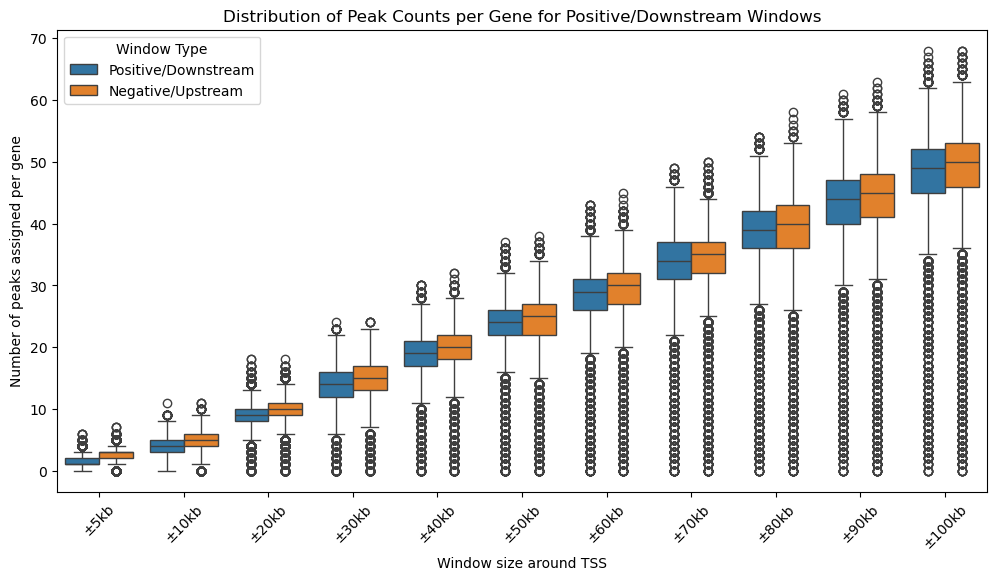

In [51]:
# Plot distribution of peaks per gene for all window sizes with seaborn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]

#peak counts per gene for each window size for both negative and positive windows
peak_counts_neg = {window: [len(peaks) for peaks in gene_peak_assignments_neg[window].values()] for window in window_sizes}
peak_counts_pos = {window: [len(peaks) for peaks in gene_peak_assignments_pos[window].values()] for window in window_sizes}

pos_data = pd.DataFrame({window: peak_counts_pos[window] for window in window_sizes})
neg_data = pd.DataFrame({window: peak_counts_neg[window] for window in window_sizes})

#melt the dataframes for seaborn but marking whether the data is from the positive or negative windows in a new column "Window Type"
pos_data_melted = pos_data.melt(var_name="Window Size", value_name="Peak Count")
pos_data_melted["Window Type"] = "Positive/Downstream"
neg_data_melted = neg_data.melt(var_name="Window Size", value_name="Peak Count")
neg_data_melted["Window Type"] = "Negative/Upstream"

#combine the melted dataframes
combined_data = pd.concat([pos_data_melted, neg_data_melted], ignore_index=True)

#plot the distributions
plt.figure(figsize=(12, 6))
sns.boxplot(x='Window Size', y='Peak Count', data=combined_data, hue='Window Type')
plt.xlabel('Window size around TSS')
plt.ylabel('Number of peaks assigned per gene')
#label the x-axis with the window sizes and rotate the labels by 45 degrees for better visibility
labels = [f"±{window}" for window in window_sizes]
plt.xticks(ticks=range(len(window_sizes)), labels=labels)
plt.title('Distribution of Peak Counts per Gene for Positive/Downstream Windows')       
plt.xticks(rotation=45)
plt.show()



In [28]:
#save the gene_peak_assignments_pos and gene_peak_assignments_neg dictionaries to csv files for each window size
for window in window_sizes:
    df = pd.DataFrame({
        "gene_id": list(gene_peak_assignments_neg[window].keys()),
        "assigned_peaks": list(gene_peak_assignments_neg[window].values())
    })
    df.to_csv(f"/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/20 windows/gene_peak_assignments_{window}_neg_upst.csv", index=False)

for window in window_sizes:
    df = pd.DataFrame({
        "gene_id": list(gene_peak_assignments_pos[window].keys()),
        "assigned_peaks": list(gene_peak_assignments_pos[window].values())
    })
    df.to_csv(f"/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/20 windows/gene_peak_assignments_{window}_pos_downst.csv", index=False)

In [52]:
# Compare assigned peaks for gene "rpl24" between dataframe and dictionary
peaks_from_df = df.loc[
    df["gene_id"] == "rpl24", "assigned_peaks"
].iloc[0]
peaks_from_dict = gene_peak_assignments_pos["100kb"]["rpl24"]

# True means both sources contain the same peak list
peaks_from_df == peaks_from_dict

True

In [27]:
#now generate window which ranges from negative kb to positive kb around the TSS for each gene, and assign peaks to these windows, and save the assigned peaks in a dictionary with the window size as key and the value being another dictionary with gene names as keys and assigned peaks as values
#read in the windows 
import pandas as pd
import ast
window_sizes = ["5kb", "10kb", "20kb", "30kb", "40kb", "50kb", "60kb", "70kb", "80kb", "90kb", "100kb"]
base_path = "/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/20 windows"

gene_peaks_neg = {}
for window in window_sizes:
    gene_peaks_neg[window] = pd.read_csv(f"{base_path}/gene_peak_assignments_{window}_neg_upst.csv")

gene_peaks_pos = {}
for window in window_sizes:
    gene_peaks_pos[window] = pd.read_csv(f"{base_path}/gene_peak_assignments_{window}_pos_downst.csv")

#combine the positive and negative window dataframes by combining all assigned peaks for each gene across all window sizes for both positive and negative windows, and save these combined dataframes to new csv files, with a column indicating whether the peaks are from the positive or negative windows
combined_gene_peaks = {}
for window in window_sizes:
    neg_df = gene_peaks_neg[window].copy()
    pos_df = gene_peaks_pos[window].copy()
    #combine the assigned peaks for each gene across both windows by concatenating the dataframes and grouping by gene_id, and saving the combined assigned peaks 
    combined_df = pd.concat([neg_df, pos_df], ignore_index=True)
    combined_df = combined_df.groupby("gene_id")["assigned_peaks"].apply(lambda x: list(set(ast.literal_eval(x.iloc[0]) + ast.literal_eval(x.iloc[1])))).reset_index()
    combined_gene_peaks[window] = combined_df
    combined_df.to_csv(f"{base_path}/combined_gene_peak_assignments_{window}.csv", index=False)


In [28]:
combined_gene_peaks

{'5kb':       gene_id                                     assigned_peaks
 0        a1cf  [12-6176521-6177141, 12-6174866-6175973, 12-61...
 1        a2ml  [15-21132969-21133231, 15-21136218-21136422, 1...
 2        aaas                 [9-249047-250089, 9-251006-251939]
 3        aacs  [5-18899208-18900460, 5-18898210-18898918, 5-1...
 4       aadac  [15-1076654-1077459, 15-1073465-1074567, 15-10...
 ...       ...                                                ...
 19375  zwilch  [18-19451998-19452226, 18-19454477-19455146, 1...
 19376   zyg11  [20-16171972-16172191, 20-16177538-16177940, 2...
 19377     zyx  [16-17347595-17348210, 16-17346794-17347029, 1...
 19378   zzef1  [5-31040700-31041157, 5-31033021-31033930, 5-3...
 19379    zzz3  [2-8776064-8776972, 2-8777324-8778066, 2-87814...
 
 [19380 rows x 2 columns],
 '10kb':       gene_id                                     assigned_peaks
 0        a1cf  [12-6186644-6187111, 12-6174866-6175973, 12-61...
 1        a2ml  [15-21132969-211

In [23]:
# Show the peaks for gene "rpl24" from both sources of window 10kb to check if they are the same
print("Peaks for rpl24 from negative window dataframe:")
print(gene_peaks_neg["10kb"].loc[gene_peaks_neg["10kb"]["gene_id"] == "rpl24", "assigned_peaks"].iloc[0])
print("Peaks for rpl24 from positive window dataframe:")
print(gene_peaks_pos["10kb"].loc[gene_peaks_pos["10kb"]["gene_id"] == "rpl24", "assigned_peaks"].iloc[0])

print("Peaks for rpl24 from combined dataframe:")
print(combined_gene_peaks["10kb"].loc[combined_gene_peaks["10kb"]["gene_id"] == "rpl24", "assigned_peaks"].iloc[0])

#compare the peaks for gene "rpl24" from the combined dataframe to the peaks in the pb_atac_ct_peaks dataframe for the 10kb window size, to check if they are correct
pos = gene_peaks_neg["10kb"].loc[gene_peaks_neg["10kb"]["gene_id"] == "rpl24", "assigned_peaks"].iloc[0]
neg = gene_peaks_pos["10kb"].loc[gene_peaks_pos["10kb"]["gene_id"] == "rpl24", "assigned_peaks"].iloc[0]
combined = combined_gene_peaks["10kb"].loc[combined_gene_peaks["10kb"]["gene_id"] == "rpl24", "assigned_peaks"].iloc[0]

#compare the peaks from pos and neg to the combined peaks, and print whether they are the same or not
print("Peaks from neg & pos window match combined peaks:", set(sorted(pos)) | set(sorted(neg)) == set(sorted(combined)))

Peaks for rpl24 from negative window dataframe:
['1-11007-12962', '1-13276-13705', '1-14059-14260', '1-14625-15105', '1-15724-15934', '1-16762-17233', '1-17587-18215', '1-18372-20466', '1-21199-21555']
Peaks for rpl24 from positive window dataframe:
['1-2372-3057', '1-3427-4032', '1-4469-7268', '1-9541-9969']
Peaks for rpl24 from combined dataframe:
['1-2372-3057', '1-9541-9969', '1-17587-18215', '1-4469-7268', '1-3427-4032', '1-21199-21555', '1-14625-15105', '1-13276-13705', '1-15724-15934', '1-16762-17233', '1-18372-20466', '1-14059-14260', '1-11007-12962']
Peaks from neg & pos window match combined peaks: False


In [24]:
import pandas as pd
combined_gene_peaks = pd.read_csv(f"{base_path}/combined_gene_peak_assignments_10kb.csv")
combined_gene_peaks.loc[combined_gene_peaks["gene_id"] == "rpl24", "assigned_peaks"].iloc[0]

"['1-2372-3057', '1-9541-9969', '1-17587-18215', '1-4469-7268', '1-3427-4032', '1-21199-21555', '1-14625-15105', '1-13276-13705', '1-15724-15934', '1-16762-17233', '1-18372-20466', '1-14059-14260', '1-11007-12962']"